# Multi-Layer Perceptron (MLP)

## Here, we use an MLP model to predict the `reliability` column of articles using metadata of speakers.







### Import dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = '/content/drive/MyDrive/BT4222/data/df_feature_engineering.parquet'
df = pd.read_parquet(file_path)
df.head()

Mounted at /content/drive


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290


In [ ]:
df.columns.tolist()

['id',
 'label',
 'statement',
 'subject',
 'speaker',
 'speaker_job_title',
 'state_info',
 'party_affiliation',
 'barely_true_counts',
 'false_counts',
 'half_true_counts',
 'mostly_true_counts',
 'pants_on_fire_counts',
 'context',
 'date',
 'true_counts',
 'total_counts',
 'label_barely-true',
 'label_false',
 'label_half-true',
 'label_mostly-true',
 'label_pants-fire',
 'label_true',
 'statement_embedding',
 'subject_embedding',
 'state_info_encoded',
 'party_affiliation_encoded',
 'speaker_job_title_embedding',
 'context_embedding',
 'sentiment_polarity',
 'sentiment_subjectivity']

### Group by Speaker to Get Counts

- We group the dataset by each speaker to count how many times they received each truthfulness label (e.g., "true", "false", "pants-on-fire")

- We +1 to the count corresponding to the ground truth label of each article, in order to account for the individual article's truthfulness

- We also sort the dataset by speaker and the date of their statements to track their history over time, for better visualisation of the label counts



In [ ]:
import pandas as pd
import numpy as np

df_new = df.copy()

def update_counts(row):
    if row['label'] == 'true':
        row['true_counts'] += 1
    elif row['label'] == 'mostly-true':
        row['mostly_true_counts'] += 1
    elif row['label'] == 'half-true':
        row['half_true_counts'] += 1
    elif row['label'] == 'barely-true':
        row['barely_true_counts'] += 1
    elif row['label'] == 'false':
        row['false_counts'] += 1
    elif row['label'] == 'pants-fire':
        row['pants_on_fire_counts'] += 1
    return row

df_new = df_new.apply(update_counts, axis=1)

# Make sure 'date' is datetime
df_new['date'] = pd.to_datetime(df_new['date'])


# Sort by speaker and date
df_new = df_new.sort_values(by=['speaker', 'date'])

df_new.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,3.0,0.0,...,0,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290



### Creating Reliability Score

- We assign each speaker a reliability score based on the weighted sum of their past truthfulness labels.

- Different labels are given different weights depending on how truthful they are (e.g., "true" gets a higher positive weight, "pants-on-fire" gets a strong negative weight).  

- The final score determines whether the speaker is considered reliable (1) or unreliable (0), depending on whether the weighted score is positive or negative.


In [ ]:
df_1 = df_new.copy()
# initially the counts were weighted equally but that gives a problem of comparing trueish and falseish because if there is 1 count of pants of fire it wouldnt over ride 1 count of barely-true
# Assign weights
weights = {
    'true_counts': 0.75,
    'mostly_true_counts': 0.5,
    'half_true_counts': 0.25,
    'barely_true_counts': -0.25,
    'false_counts': -0.75,
    'pants_on_fire_counts': -1.0
}

# Apply weighted sum for a reliability score
df_1['weighted_score'] = (
    df_1['true_counts'] * weights['true_counts'] +
    df_1['mostly_true_counts'] * weights['mostly_true_counts'] +
    df_1['half_true_counts'] * weights['half_true_counts'] +
    df_1['barely_true_counts'] * weights['barely_true_counts'] +
    df_1['false_counts'] * weights['false_counts'] +
    df_1['pants_on_fire_counts'] * weights['pants_on_fire_counts']
)

# Set reliability: 1 if score > 0, else 0
df_1['reliability'] = (df_1['weighted_score'] > 0).astype(int)

df_1.head()

,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity,weighted_score,reliability
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455,0.50,1
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000,0.50,1
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000,-1.25,0
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,3.0,0.0,...,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455,-1.75,0
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290,-2.50,0


### Preparing Metadata Features for MLP Model

- We encode the `speaker` column using LabelEncoder so that the model can process it as a numeric value.

- We then extract two types of metadata features:  
  1. Embedding-based features (`speaker_job_title_embedding`, `context_embedding`)  
  2. Categorical metadata (`state_info_encoded`, `party_affiliation_encoded`, `speaker_encoded`)  

- These features are combined into a single input matrix `X`, which is used to train the model.

- The target label `y` corresponds to the `reliability` column, which indicates whether a speaker is reliable or not.





In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode `speaker`
le = LabelEncoder()
df_1['speaker_encoded'] = le.fit_transform(df_1['speaker'])

# Select features
embedding_cols = [
    'speaker_job_title_embedding',
    'context_embedding'
]

flat_embeddings = np.hstack([
    np.vstack(df_1[col].values) for col in embedding_cols
])

# Select non-embedding features
meta_cols = [
    'state_info_encoded',
    'party_affiliation_encoded',
    'speaker_encoded'
]
meta_features = df_1[meta_cols].values

# Combine all features
X = np.hstack([flat_embeddings, meta_features])
print(X.shape)

# Target label (reliability)
y = df_1['reliability'].values

(12786, 771)


### Train, Validation, Test Set Split

We applied a two-stage split to prepare our data:

- First, we divided the original dataset into **80% training** and **20% testing**.
- Next, we further split the training set into **80% training** and **20% validation**

In [ ]:
from sklearn.model_selection import train_test_split

# First split: train + temp (which will be split again into val + test)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: from training set, take 20% as validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

### Converting Data to PyTorch Tensors and Preparing DataLoaders
- We convert our training, validation, and test sets into PyTorch tensors, which are required inputs for model training in PyTorch.
- The feature data is cast to float32, while labels are also kept as floats to match the requirements for binary classification.

- Each pair of features and labels is wrapped into a `TensorDataset`, and then loaded into a `DataLoader` to facilitate efficient mini-batch training and evaluation.
- We set a batch size of 256 and enable shuffling for the training set to improve learning stability.


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors (ensure float32 for features, long/int for labels)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Wrap in TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


### Define MLP Model

We define a Multi-Layer Perceptron (MLP) model using PyTorch to classify speaker reliability based on structured metadata features. The architecture includes the following components:

- **Input Layer**: Accepts a feature vector of size `771` (i.e., `input_dim = 771`).
- **First Hidden Layer**:
  - Linear transformation from `771` to `64` dimensions (`nn.Linear(input_dim, 64)`).
  - Batch Normalization over 64 features (`nn.BatchNorm1d(64)`).
  - ReLU activation to introduce non-linearity.
- **Dropout Layer**: Applies dropout with probability `0.3` to the output of the first hidden layer for regularization.
- **Second Hidden Layer**:
  - Linear transformation from `64` to `32` dimensions (`nn.Linear(64, 32)`).
  - Batch Normalization over 32 features (`nn.BatchNorm1d(32)`).
  - ReLU activation.
- **Dropout Layer**: Another dropout with probability `0.3` after the second hidden layer.
- **Output Layer**:
  - Final linear layer from `32` to `1` node (`nn.Linear(32, 1)`).
  - Sigmoid activation to output a probability score between 0 and 1, representing the likelihood that the speaker is reliable (`1`) or not (`0`).

The model is deployed on GPU (`cuda`) if available, otherwise defaults to CPU. This architecture balances complexity and generalization, making it well-suited for binary classification using high-dimensional metadata inputs.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout_prob=0.3):
        super(MLPClassifier, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.dropout1 = nn.Dropout(p=dropout_prob)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        self.dropout2 = nn.Dropout(p=dropout_prob)

        self.out = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        return torch.sigmoid(self.out(x))


input_dim = X_train.shape[1]
model = MLPClassifier(input_dim=input_dim).to("cuda" if torch.cuda.is_available() else "cpu")

### Train the Model and Evaluate on Validation Set

- We trained our MLP model for 10 epochs using the Adam optimizer with a learning rate of `0.0001`.

- The Binary Cross-Entropy Loss (`BCELoss`) function was used, which is appropriate for our binary classification task of predicting speaker reliability.

- Each epoch involved setting the model to training mode, computing the loss, and updating model weights via backpropagation. After each training pass, we evaluated the model on the validation set. Predictions were thresholded at `0.5` to classify speakers as either reliable (`1`) or unreliable (`0`), and validation accuracy was calculated based on the proportion of correct predictions.

- Before finalizing the training configuration, we experimented with several combinations of hyperparameters, including learning rates, hidden layer sizes, dropout probabilities, and batch sizes. The final configuration was selected based on the best validation accuracy and training consistency:

  - **Learning rate**: `0.0001` — struck a balance between convergence speed and stability  
  - **Hidden dimensions**: `[64, 32]` — provided sufficient representational power without overfitting  
  - **Dropout rate**: `0.3` — added regularization to improve generalization  
  - **Batch size**: `256` — optimized performance and memory usage  

- This iterative tuning process allowed us to build a model that not only learned effectively from the training data but also generalized well on unseen validation inputs.



In [ ]:
from torch.optim import Adam
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.0001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)

        preds = model(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation loop
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb).squeeze()
            preds = (outputs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    # Metrics
    val_acc = accuracy_score(all_labels, all_preds)
    val_precision = precision_score(all_labels, all_preds)
    val_recall = recall_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f} - "
          f"Val Acc: {val_acc:.4f} - Precision: {val_precision:.4f} - "
          f"Recall: {val_recall:.4f} - F1: {val_f1:.4f}")


Epoch 1/10 - Loss: 22.6876 - Val Acc: 0.5484 - Precision: 0.5361 - Recall: 0.5361 - F1: 0.5361
Epoch 2/10 - Loss: 22.2434 - Val Acc: 0.5499 - Precision: 0.5285 - Recall: 0.6978 - F1: 0.6015
Epoch 3/10 - Loss: 21.6426 - Val Acc: 0.5890 - Precision: 0.5679 - Recall: 0.6506 - F1: 0.6065
Epoch 4/10 - Loss: 21.0273 - Val Acc: 0.6584 - Precision: 0.6612 - Recall: 0.6114 - F1: 0.6354
Epoch 5/10 - Loss: 20.5707 - Val Acc: 0.6398 - Precision: 0.6145 - Recall: 0.6978 - F1: 0.6535
Epoch 6/10 - Loss: 20.2812 - Val Acc: 0.6554 - Precision: 0.6346 - Recall: 0.6888 - F1: 0.6606
Epoch 7/10 - Loss: 20.0072 - Val Acc: 0.6711 - Precision: 0.6800 - Recall: 0.6124 - F1: 0.6445
Epoch 8/10 - Loss: 19.7207 - Val Acc: 0.6535 - Precision: 0.6153 - Recall: 0.7691 - F1: 0.6836
Epoch 9/10 - Loss: 19.6095 - Val Acc: 0.6672 - Precision: 0.6612 - Recall: 0.6486 - F1: 0.6548
Epoch 10/10 - Loss: 19.5169 - Val Acc: 0.6711 - Precision: 0.6829 - Recall: 0.6054 - F1: 0.6418


### Combined Train + Validation Evaluation

To generate a more comprehensive performance evaluation, we re-ran our trained MLP model on the combined training and validation datasets.

- **Dataset Concatenation**: We used `ConcatDataset` to merge the training and validation sets into a single unified dataset, ensuring the model is evaluated on all data it has seen during training and tuning.

- **Model Evaluation**: The model was set to evaluation mode using `model.eval()`, and predictions were generated without gradient computation (`torch.no_grad()`).

- **Prediction and Metrics**:
  - For each batch, we generated binary predictions using a 0.5 threshold.
  - Predictions and true labels were stored in lists for final metric computation.
  - We used `accuracy_score`, `precision_score`, `recall_score`, and `f1_score` from `sklearn.metrics` to report evaluation results.

- **Results**:
  - **Accuracy**: 67.90%
  - **Precision**: 68.38%
  - **Recall**: 63.40%
  - **F1 Score**: 65.80%


In [ ]:
from torch.utils.data import ConcatDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Combine train and validation datasets
combined_dataset = ConcatDataset([train_dataset, val_dataset])
combined_loader = DataLoader(combined_dataset, batch_size=256, shuffle=False)

# Switch model to evaluation mode
model.eval()
all_preds = []
all_labels = []

# Generate predictions
with torch.no_grad():
    for xb, yb in combined_loader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb).squeeze()
        preds = (outputs > 0.5).int()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# Compute final metrics
val_acc = accuracy_score(all_labels, all_preds)
val_precision = precision_score(all_labels, all_preds)
val_recall = recall_score(all_labels, all_preds)
val_f1 = f1_score(all_labels, all_preds)

# Print results
print(f"Combined Evaluation - Accuracy: {val_acc:.4f} | "
      f"Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1 Score: {val_f1:.4f}")


Combined Evaluation - Accuracy: 0.6790 | Precision: 0.6838 | Recall: 0.6340 | F1 Score: 0.6580


### Test Loop and Evaluation

- After training the MLP model, we evaluated its performance on the test set using a variety of classification metrics. During this phase, the model was switched to evaluation mode, and no gradient updates were performed.

- We collected three types of outputs for each batch in the test set:
  - **Predicted binary labels** (0 or 1), by applying a threshold of 0.5 on the model's sigmoid outputs.
  - **True labels**, representing the actual reliability.
  - **Predicted probabilities**, used to calculate AUC-ROC metrics.

- We computed key evaluation metrics, including accuracy, precision, recall, F1 score, and the confusion matrix to understand model performance.

- To go further, we plotted the **Receiver Operating Characteristic (ROC) curve** and calculated the **Area Under the Curve (AUC)** score, which provides a threshold-independent view of how well the model separates reliable and unreliable speakers.



Test Accuracy: 67.5919%
Precision: 67.5949%
Recall: 64.2857%
F1 Score: 65.8988%
ROC AUC Score: 0.7568
Confusion Matrix:
[[928 384]
 [445 801]]


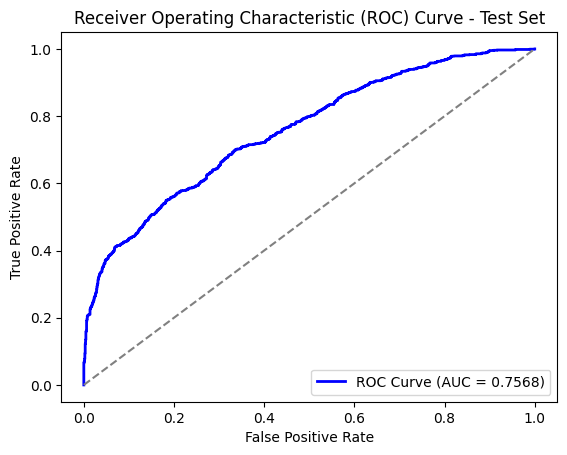

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []
all_probs = []  # Collect predicted probabilities for ROC and AUC

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        outputs = model(xb).squeeze()  # Predicted probabilities
        preds = (outputs > 0.5).int()  # Convert to binary labels: 0 or 1

        all_preds.extend(preds.cpu().tolist())  # Binary predictions
        all_labels.extend(yb.cpu().tolist())   # True labels
        all_probs.extend(outputs.cpu().tolist())  # Predicted probabilities

# Compute metrics
accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, zero_division=0) * 100
recall = recall_score(all_labels, all_preds, zero_division=0) * 100
f1 = f1_score(all_labels, all_preds, zero_division=0) * 100
conf_matrix = confusion_matrix(all_labels, all_preds)

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(all_labels, all_probs) # Use probabilities for ROC curve
roc_auc = roc_auc_score(all_labels, all_probs) # Compute AUC score

# Print results
print(f"Test Accuracy: {accuracy:.4f}%")
print(f"Precision: {precision:.4f}%")
print(f"Recall: {recall:.4f}%")
print(f"F1 Score: {f1:.4f}%")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.show()

#### Evaluation of results

The model achieved:
- Accuracy: 67.5919%
- Precision: 67.5949%
- Recall: 64.2857%
- F1 Score: 65.8988%
- ROC AUC Score: 0.7568


This evaluation highlighted that the model was cautious with positive classifications (higher precision), though it missed some true positives (moderate recall).

The AUC of 0.7568 confirms the model’s ability to distinguish between classes across various thresholds.

The ROC curve plot visually reinforced this, showing a curve well above the random classifier line, suggesting good discriminative ability.

The confusion matrix further provided insight into the types of errors made, such as the 384 false positives and 445 false negatives.

### Exporting MLP Predictions for Ensemble Use

- After training the final MLP model, we use it to generate predicted probabilities across the entire dataset. These probabilities reflect the model’s confidence in classifying each speaker as reliable. The model is set to evaluation mode (`model.eval()`), and inference is performed without gradient tracking using `torch.no_grad()` to improve efficiency.

- The predicted probabilities are produced from the sigmoid output of the model and represent continuous scores between 0 and 1. We extract the corresponding `id` values and pair them with the predicted probabilities.

- A final DataFrame is created with two columns:
  - `id`: the article's unique identifier
  - `predicted_probability`: the MLP model’s predicted probability of reliability

- This DataFrame is then exported as a CSV file and saved to Google Drive. The output is intended for use in the ensemble model, where it will be combined with predictions from other models like BERT and XGBoost.


In [ ]:
model.eval()
all_ids = df_1['id'].values
all_probs = []

with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    outputs = model(X_tensor).squeeze()
    all_probs.extend(outputs.cpu().tolist())

# Create a DataFrame with IDs and predicted probabilities
results_df = pd.DataFrame({'id': all_ids, 'predicted_probability': all_probs})

# Save to CSV
csv_file_path = '/content/drive/My Drive/BT4222/data/mlp_predictions.csv'
results_df.to_csv(csv_file_path, index=False)

print(f"Predictions saved to Google Drive at {csv_file_path}.")
results_df.head()

Predictions saved to Google Drive at /content/drive/My Drive/BT4222/data/mlp_predictions.csv.


,id,predicted_probability
0,7874.json,0.451341
1,13412.json,0.387204
2,2287.json,0.409137
3,2426.json,0.378775
4,4832.json,0.391959
